# Сжатие изображений с помощью SVD

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import mean_squared_error

## Часть А. Загрузка и подготовка данных

Форма: (512, 512, 3)


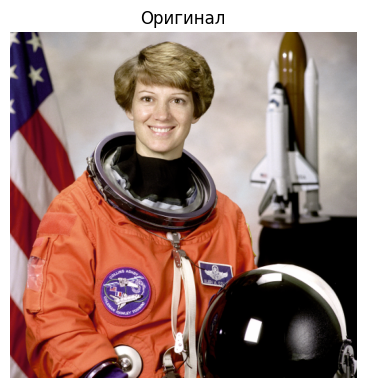

In [2]:
from skimage import data
img_array = data.astronaut()   # цветное изображение 512x512x3

# для своей фотографии:
# img_array = np.array(Image.open('my_pic.jpg').convert('RGB'))

original = img_array.astype(np.float64)
original_shape = original.shape
h, w, c = original_shape
original_flat = original.flatten()

print('Форма:', original_shape)

plt.figure(figsize=(4.5, 4.5))
plt.imshow(img_array)
plt.title('Оригинал')
plt.axis('off')
plt.show()

Изображение загружено как массив (512, 512, 3), значения 0–255. Использую вариант Б: SVD по каждому RGB-каналу отдельно.

## Часть Б. SVD и восстановление

In [3]:
svd_per_channel = [np.linalg.svd(original[:, :, ch], full_matrices=False)
                   for ch in range(c)]

def reconstruct_rgb(r):
    channels = [(U[:, :r] * s[:r]) @ Vt[:r, :] for (U, s, Vt) in svd_per_channel]
    return np.clip(np.stack(channels, axis=2), 0, 255)

max_rank = min(h, w)
list_of_ranks = [1, 5, 10, 30, 100, max_rank]
approximations = [reconstruct_rgb(r) for r in list_of_ranks]

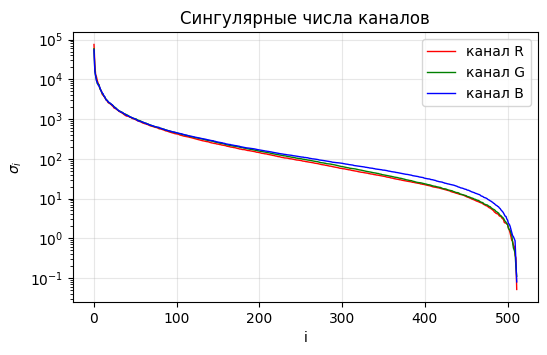

In [4]:
plt.figure(figsize=(6, 3.5))
for ch, (U, s, Vt) in enumerate(svd_per_channel):
    plt.semilogy(s, color='rgb'[ch], label='канал ' + 'RGB'[ch], lw=1)
plt.xlabel('i'); plt.ylabel(r'$\sigma_i$')
plt.title('Сингулярные числа каналов')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Сингулярные числа быстро убывают — первые десятки компонент несут почти всю информацию, поэтому низкоранговая аппроксимация работает.

## Часть В. Визуализация

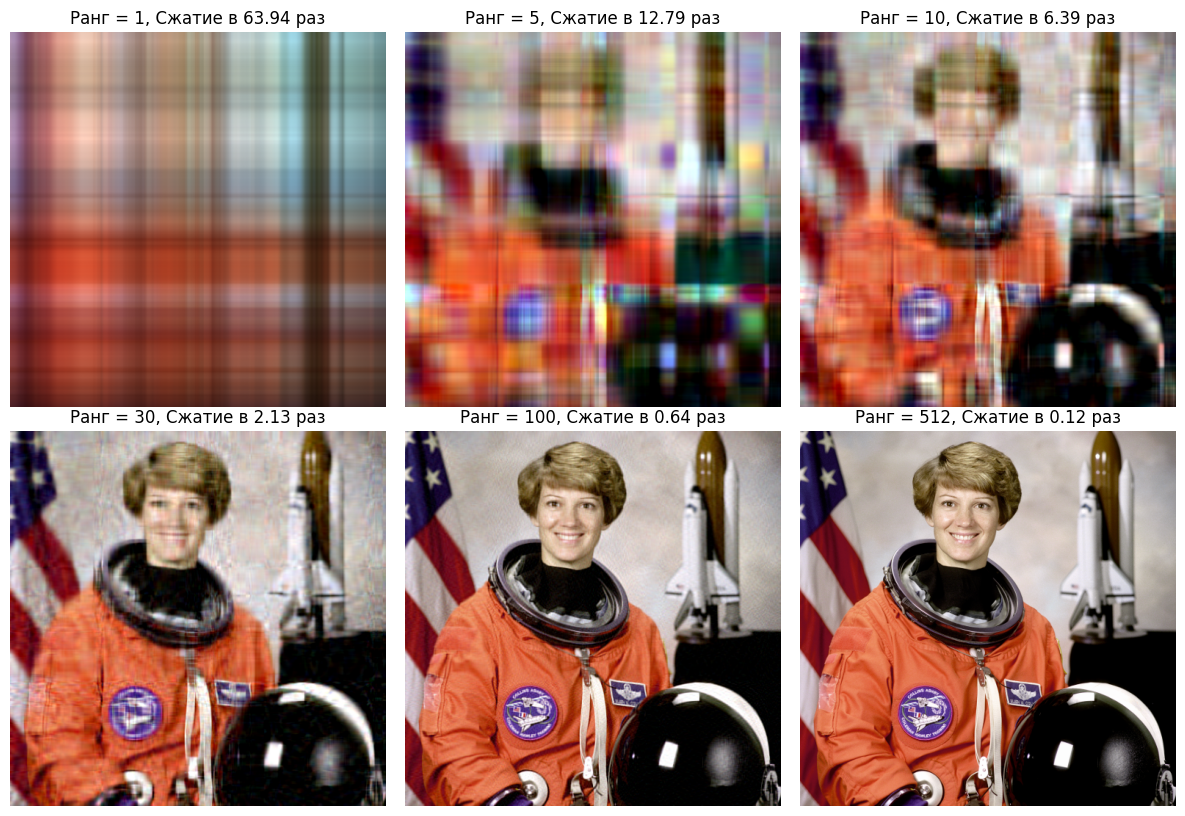

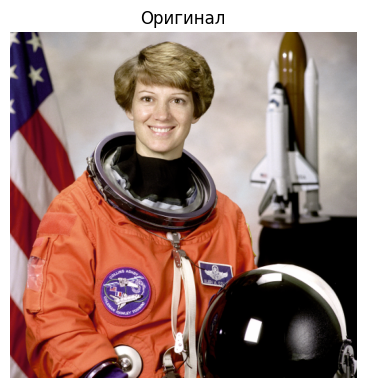

In [5]:
BYTES_PER_FLOAT = 4                # храним сжатое как float32
original_bytes = 3 * h * w         # 1 байт на канал

def compression_ratio(r):
    return original_bytes / (3 * r * (h + 1 + w) * BYTES_PER_FLOAT)

fig, axes = plt.subplots(2, 3, figsize=(12, 8.2))
for ax, r, approx in zip(axes.flat, list_of_ranks, approximations):
    ax.imshow(approx.astype(np.uint8))
    ax.set_title(f'Ранг = {r}, Сжатие в {compression_ratio(r):.2f} раз')
    ax.axis('off')
plt.tight_layout(); plt.show()

plt.figure(figsize=(4.5, 4.5))
plt.imshow(img_array)
plt.title('Оригинал')
plt.axis('off'); plt.show()

При r = 30 картинка узнаваема, при r = 100 уже почти не отличается от оригинала.

## Часть Г. Эффективность сжатия

In [6]:
print(f'{"r":>4} | {"сжатый размер, КБ":>18} | {"сжатие, раз":>11}')
for r in list_of_ranks:
    kb = 3 * r * (h + 1 + w) * BYTES_PER_FLOAT / 1024
    print(f'{r:>4} | {kb:>18.1f} | {compression_ratio(r):>11.2f}')

r10 = h * w / (4 * 10 * (h + 1 + w))
print(f'\nСжатие в 10 раз: r = {int(r10)} (точное значение {r10:.2f})')

   r |  сжатый размер, КБ | сжатие, раз
   1 |               12.0 |       63.94
   5 |               60.1 |       12.79
  10 |              120.1 |        6.39
  30 |              360.4 |        2.13
 100 |             1201.2 |        0.64
 512 |             6150.0 |        0.12

Сжатие в 10 раз: r = 6 (точное значение 6.39)


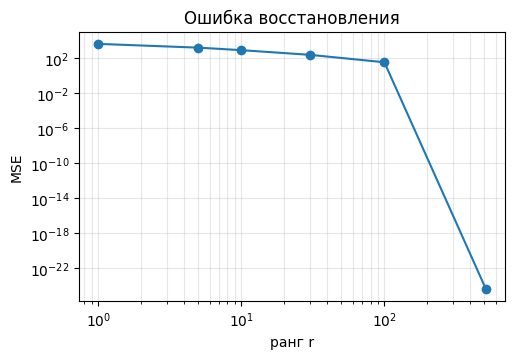

In [7]:
mse_by_rank = [mean_squared_error(original_flat, a.flatten()) for a in approximations]

plt.figure(figsize=(5.5, 3.5))
plt.loglog(list_of_ranks, mse_by_rank, 'o-')
plt.xlabel('ранг r'); plt.ylabel('MSE')
plt.title('Ошибка восстановления')
plt.grid(alpha=0.3, which='both')
plt.show()

**Ответы на вопросы:**

1. Визуально качество перестаёт отличаться от оригинала примерно при r = 100: дальше улучшается только метрика, но не восприятие. При r = 30 изображение узнаваемо, но мелкие детали смазаны.

2. Сжатие в 10 раз достигается при r = 6 (по формуле k = h·w / (4·r·(h+1+w)) для 512×512). Ранг 5 из списка даёт ~12.8 раз. При r > 63 коэффициент падает ниже 1 — хранение во float32 становится больше исходного файла.

3. Ошибка в тёмных и светлых участках разная, потому что: (а) аппроксимация осциллирует вокруг истинных значений, и у границ диапазона (около 0 и 255) колебания срезаются клиппингом по-разному; (б) наибольшая ошибка на резких перепадах яркости (эффект, похожий на явление Гиббса); (в) глаз чувствителен к относительной ошибке, поэтому тот же шум заметнее в тенях.

## Автопроверка

In [ ]:
# ---------- БЛОК АВТОПРОВЕРКИ ----------
# original_shape = (h, w, c) или (h, w)
# list_of_ranks = [1, 5, 10, 30, 100, ...]
# approximations = список восстановленных массивов (numpy) для каждого ранга

# 1. Проверка размерностей
for i, r in enumerate(list_of_ranks):
    assert approximations[i].shape == original_shape, f"Ошибка: размерность для ранга {r} не совпадает с исходной"

# 2. Проверка, что значения не выходят за пределы 0-255 (для RGB/серого)
for i, r in enumerate(list_of_ranks):
    arr = approximations[i]
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255) # Если float, то проверяем диапазон
    assert arr.max() <= 255.1, f"Значения превышают 255 для ранга {r}"
    assert arr.min() >= -0.1, f"Значения меньше 0 для ранга {r}"

# 3. Проверка, что с ростом ранга ошибка уменьшается (метрика MSE)
from sklearn.metrics import mean_squared_error
mse_list = []
for i in range(len(approximations)):
    # Если цветная, считаем MSE по всем каналам
    mse = mean_squared_error(original_flat, approximations[i].flatten())
    mse_list.append(mse)

# Проверяем монотонность (MSE должен падать, так как мы добавляем сингулярные числа)
for i in range(1, len(mse_list)):
    assert mse_list[i] <= mse_list[i-1] + 1e-6, f"MSE не уменьшается между рангами {list_of_ranks[i-1]} и {list_of_ranks[i]}"

print("✅ Все автоматические проверки пройдены. Задание выполнено корректно!")

✅ Все автоматические проверки пройдены. Задание выполнено корректно!


## Выводы

- SVD позволяет сжимать изображения: спектр сингулярных чисел быстро убывает, и малого числа компонент достаточно для восстановления без видимых потерь (r ≈ 100 из 512).
- Качество и размер регулируются одним параметром r: MSE монотонно убывает с ростом ранга, коэффициент сжатия падает как 1/r. Сжатие в 10 раз — при r = 6, но с заметной потерей качества.
- При r > 63 хранение факторов во float32 занимает больше места, чем исходные пиксели, — у метода есть предел выгодности.
- Поканальное SVD сохраняет цвет; артефакты малых рангов выглядят как цветные разводы, так как каналы аппроксимируются независимо.